# TASK 04: Classification
## Classification Models, Evaluation Metrics & Handling Imbalanced Data
1. Understand classification problems 
2. Tain and evaluate classification models
3. Use proper evaluation metrics beyond accuracy
4. Handle claa imbalance
5. Justify model performance scientifially

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

In [60]:
# Step 2: Loading dataset

data = load_breast_cancer(as_frame=True)
df = pd.concat([data.data, data.target.rename("target")], axis=1)

X = df.drop("target", axis=1)
y = df["target"]

In [61]:
# Step 3: Tain-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [62]:
#  Step 4: Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [65]:
# Step 5: Train Baseline Classification Model

#Logistic Regression

log_model = LogisticRegression(class_weight="balanced", max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]


In [66]:
# Step 6: Decision Tree

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]


In [52]:
# Step 7: Precision, Recall and F1-Score Interpretation
# Q. Which metric is more important for medical diagnosis?
# Q. What happens if recall is low?
# Q. Why F1-score is preferred for imblanced data?





In [ ]:
# Step 7: Metrics Calculation Function


def get_metrics(y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "AUC": auc(fpr, tpr)
    }

log_metrics = get_metrics(y_test, y_pred_log, y_prob_log)
tree_metrics = get_metrics(y_test, y_pred_tree, y_prob_tree)


In [70]:
#Step 8: Comparison Table


comparison_df = pd.DataFrame([log_metrics, tree_metrics],
                             index=["Logistic Regression", "Decision Tree"])

print("\n===== MODEL COMPARISON TABLE =====\n")
print(comparison_df)



===== MODEL COMPARISON TABLE =====

                     Accuracy  Precision    Recall  F1 Score      AUC
Logistic Regression  0.982456   0.985915  0.985915  0.985915  0.99738
Decision Tree        0.947368   0.957746  0.957746  0.957746  0.94399


In [74]:
# Step 9: Detailed Reports


print("\n===== Logistic Regression Report =====\n")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print("\n===== Decision Tree Report =====\n")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))


===== Logistic Regression Report =====

[[42  1]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


===== Decision Tree Report =====

[[40  3]
 [ 3 68]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



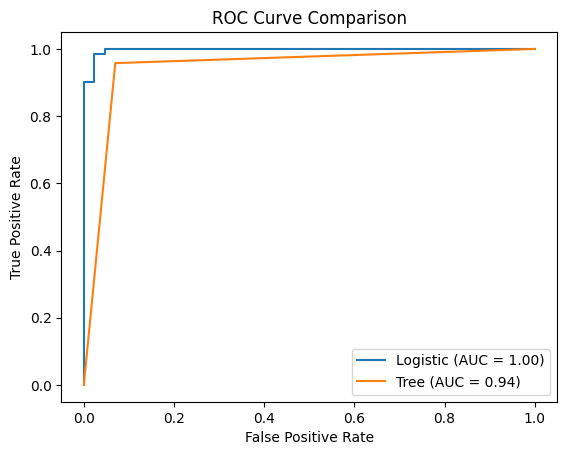

In [ ]:
# Step 10: ROC Curve Plot


fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {log_metrics['AUC']:.2f})")
plt.plot(fpr_tree, tpr_tree, label=f"Tree (AUC = {tree_metrics['AUC']:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
# Step 11: Best Model Selection


best_model = comparison_df["F1 Score"].idxmax()

print("\n===== BEST MODEL =====")
print(f"Best Model based on F1 Score: {best_model}")


===== BEST MODEL =====
Best Model based on F1 Score: Logistic Regression
